<a href="https://colab.research.google.com/github/giangan9a1truongtay-ux/-Learning_Environment_And_Exams_Analysis/blob/main/Learning_Environment_And_Exams_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PHÂN TÍCH MÔI TRƯỜNG HỌC TẬP & KỲ THI**

 **Câu hỏi :**“Điều kiện học tập và điều kiện thi có liên quan đến điểm số như thế nào?” , "Độ khó của đề có tạo ra sự khác biệt về điểm không?"


ĐÃ XUẤT THÀNH CÔNG 4 FILE ẢNH TẠI THƯ MỤC:
/content/result
 - fig1_exam_scores_avg.png
 - fig2_number_of_students_count.png
 - fig3_exam_difficulty_avg.png
 - fig4_score_distribution_boxplot.png

HIỂN THỊ CÁC BIỂU ĐỒ TRỰC TIẾP TẠI ĐÂY:

 Biểu đồ: fig1_exam_scores_avg.png


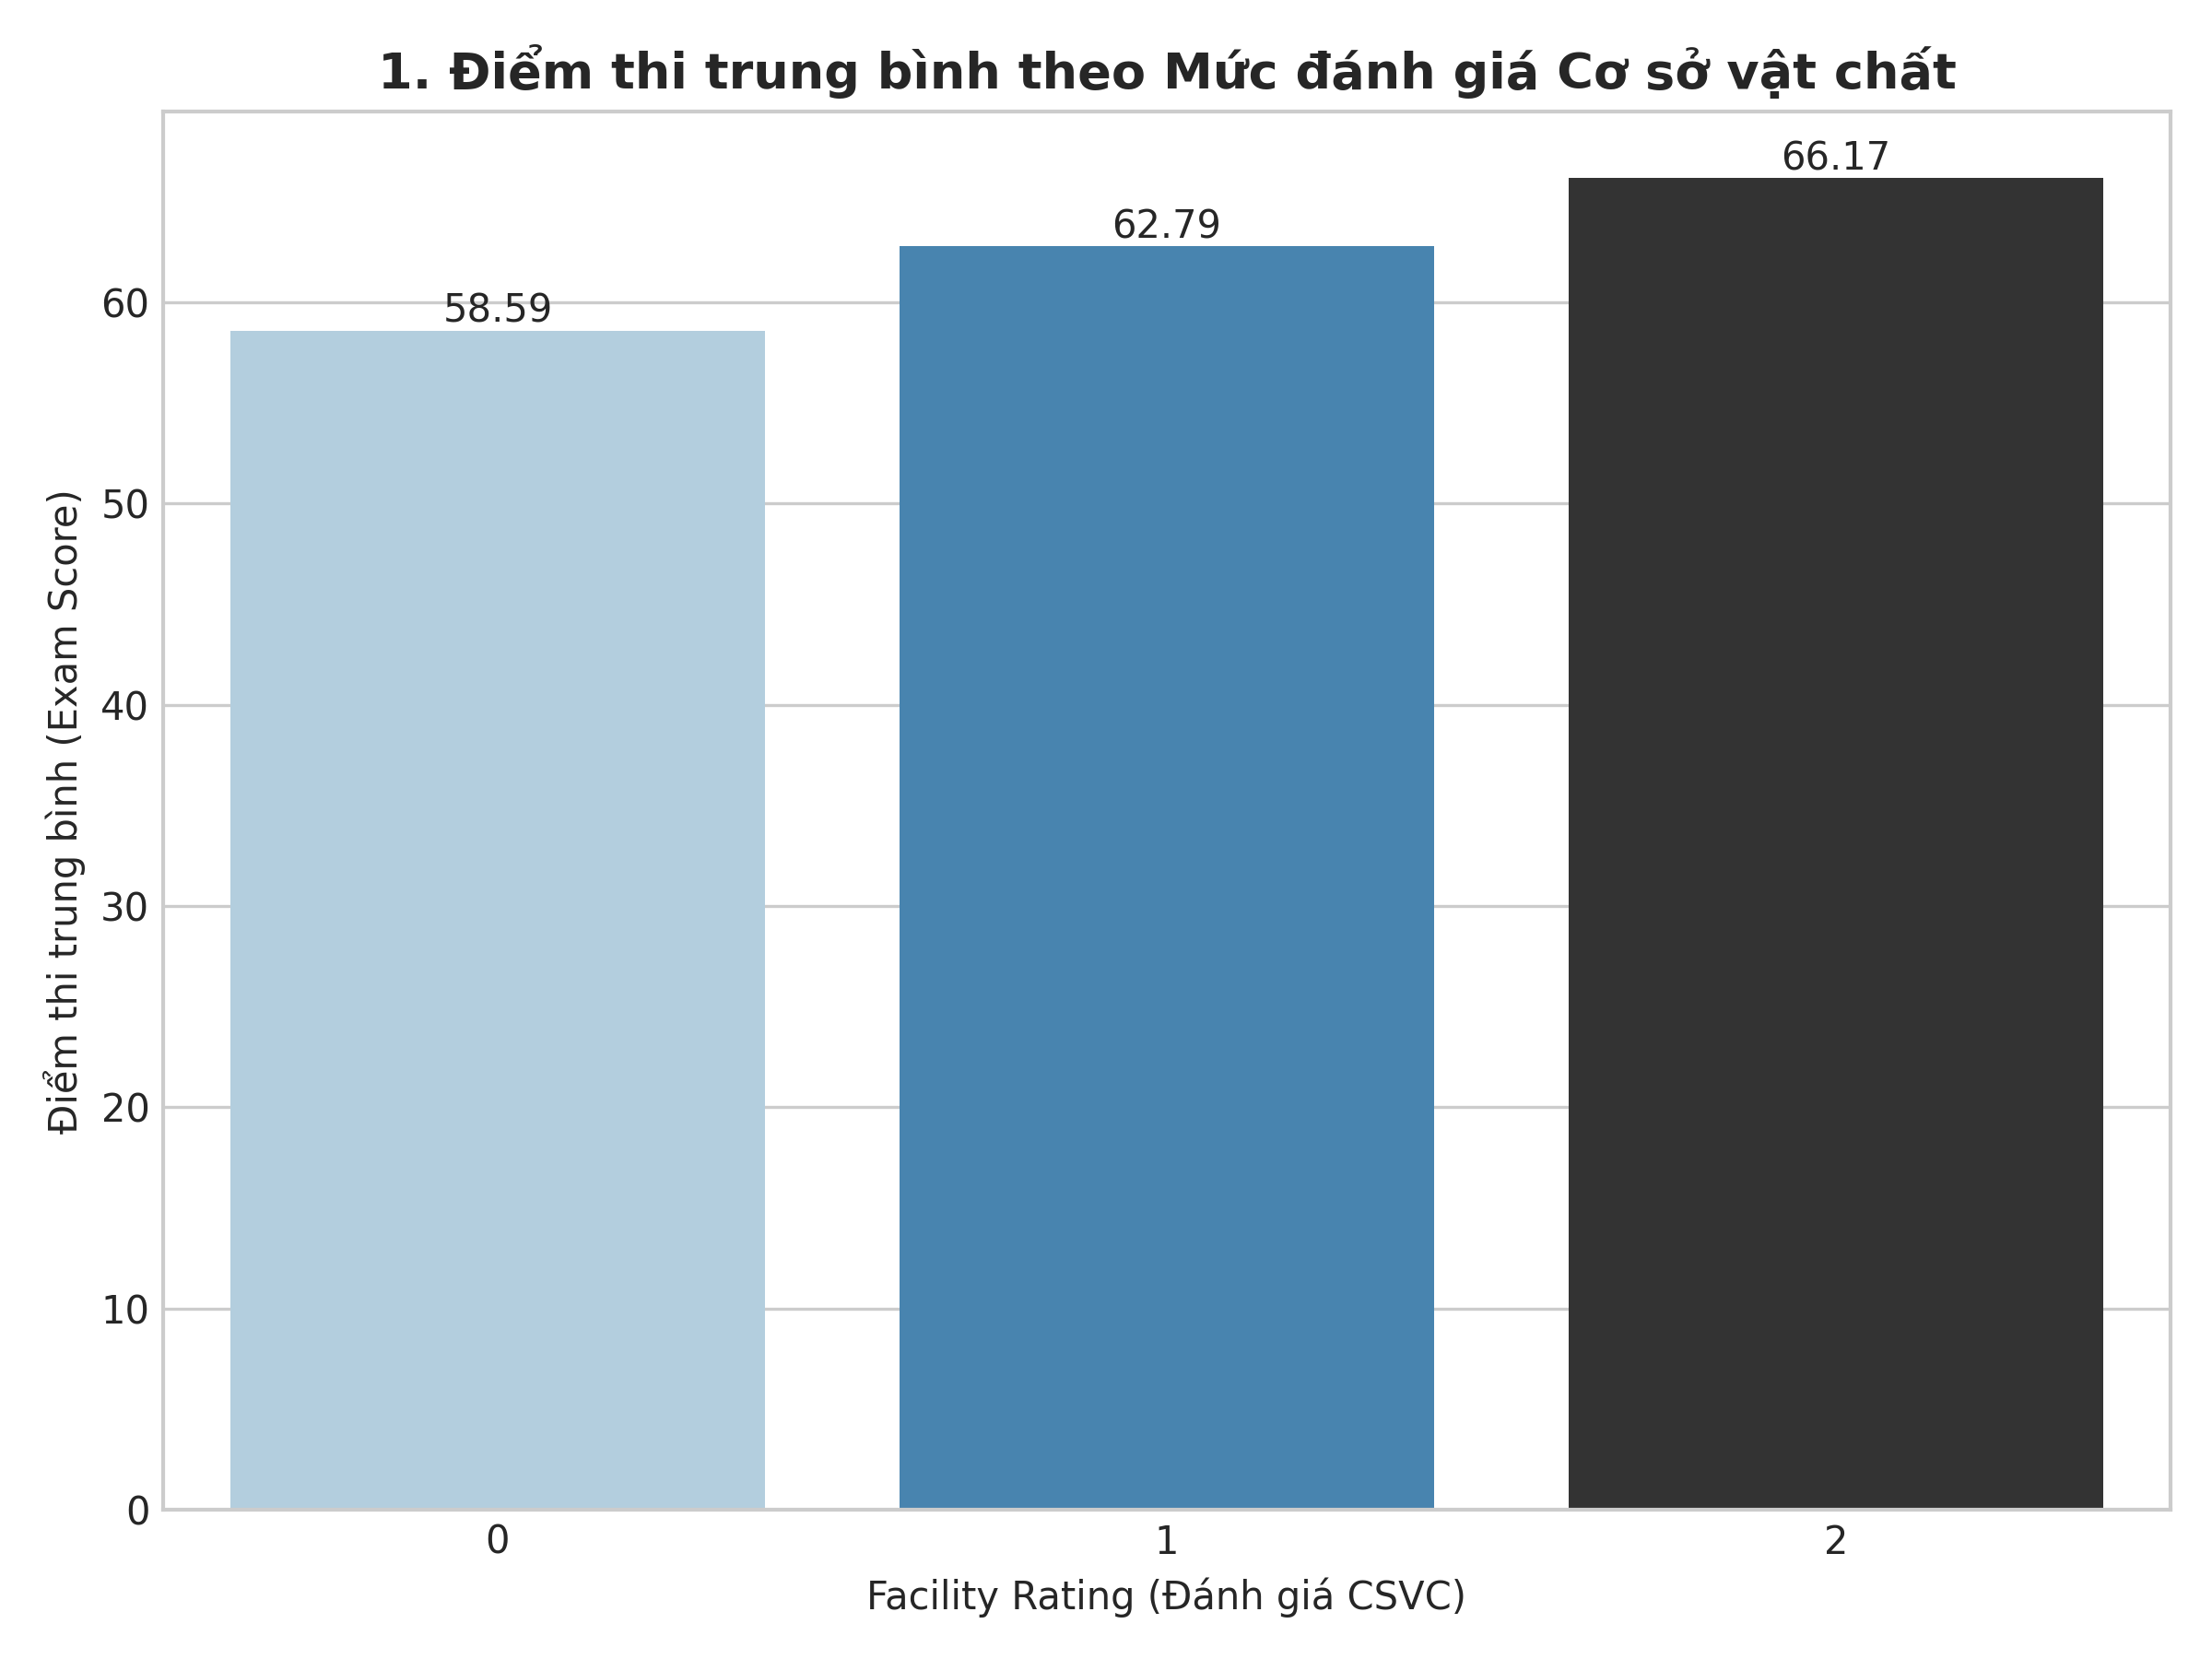


 Biểu đồ: fig2_number_of_students_count.png


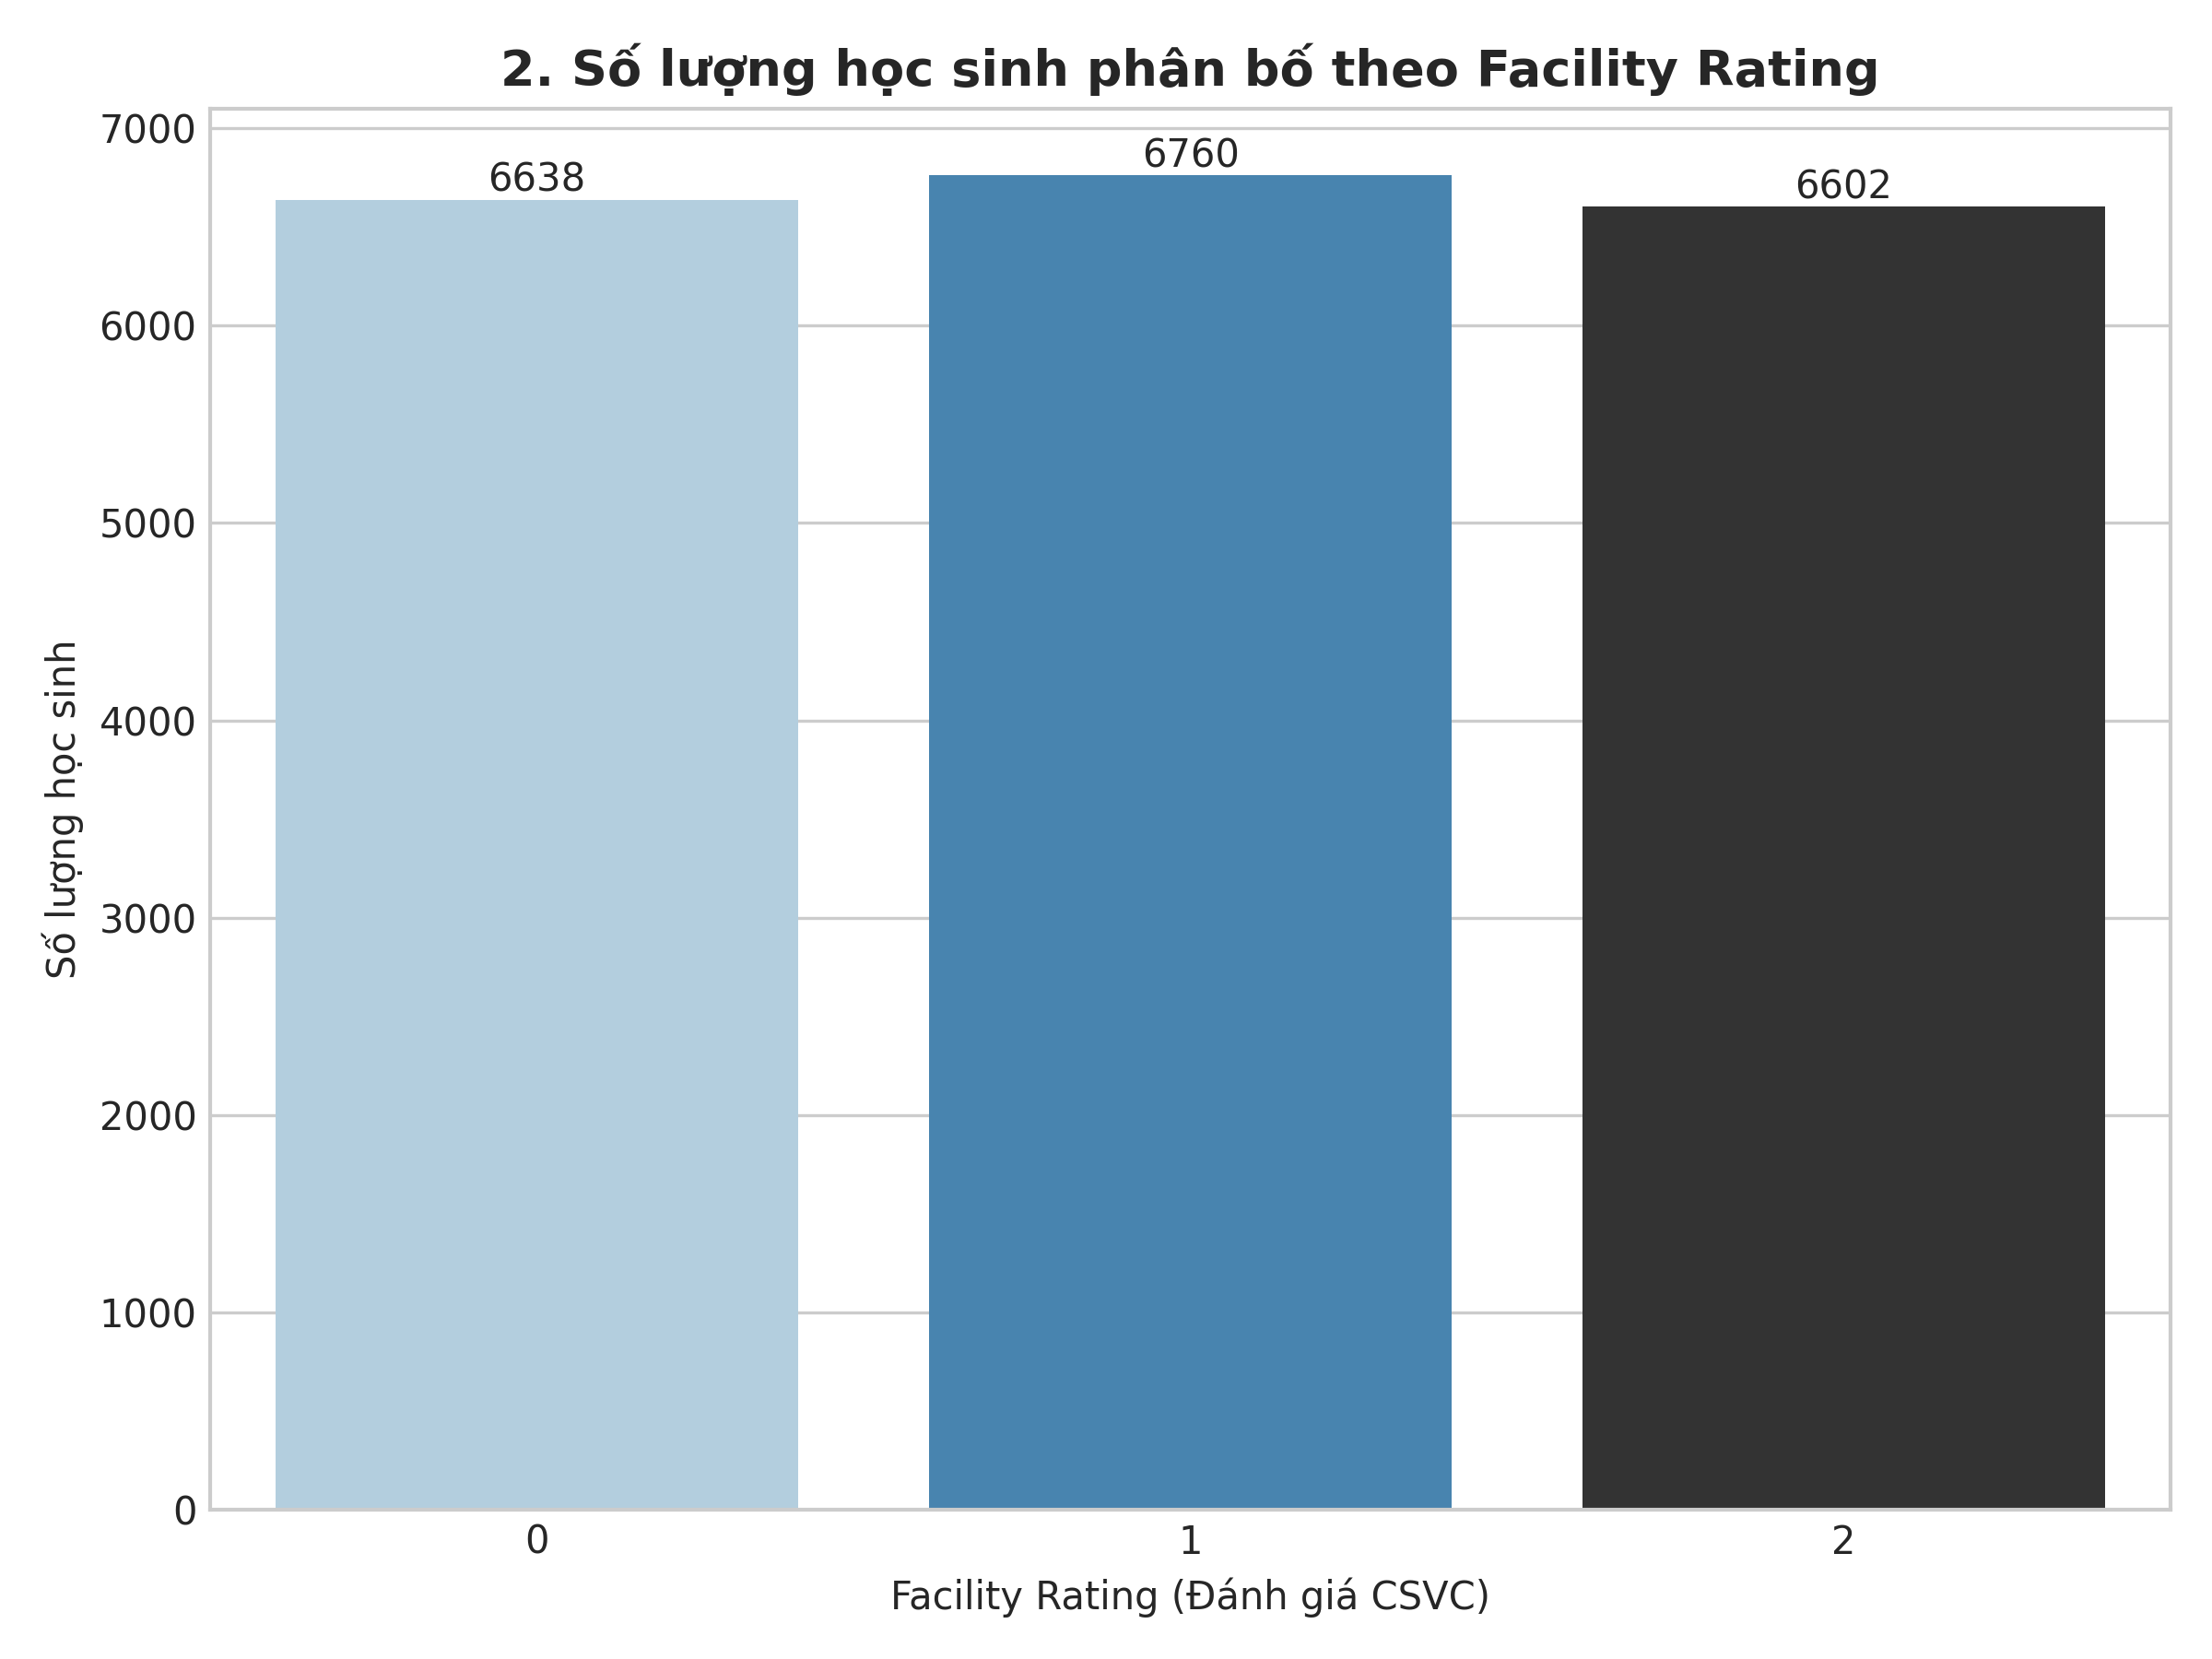


 Biểu đồ: fig3_exam_difficulty_avg.png


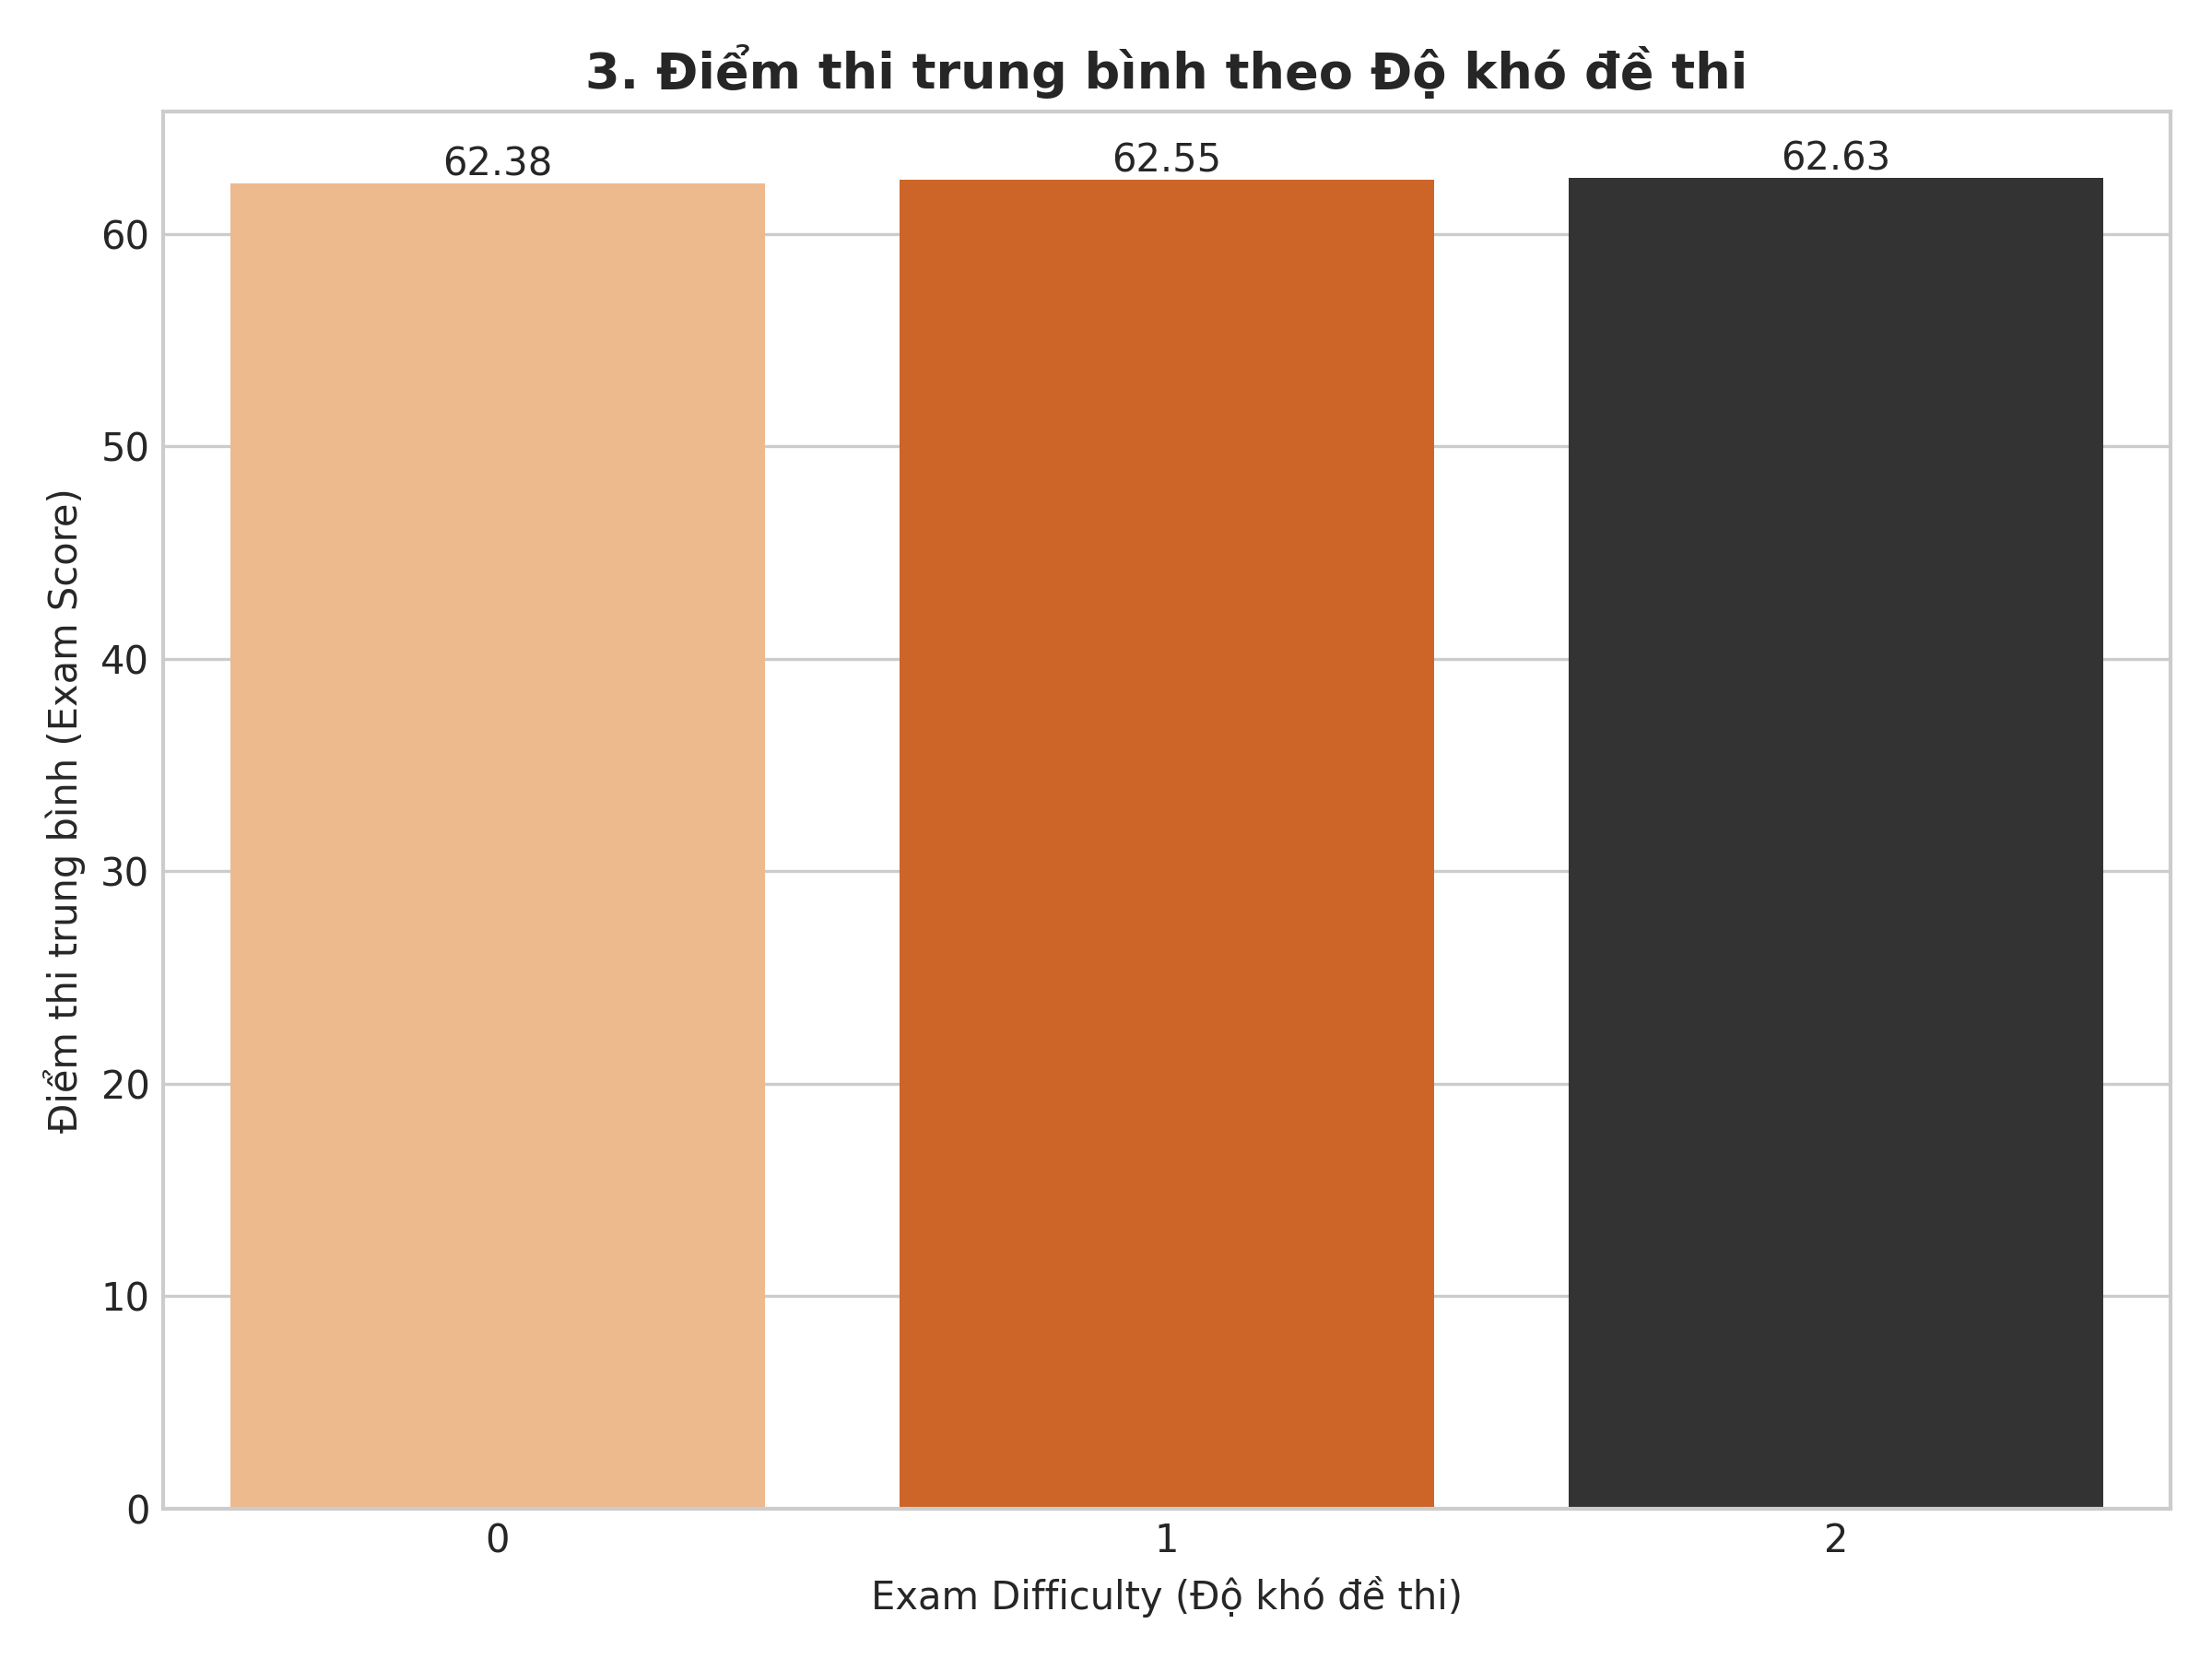


 Biểu đồ: fig4_score_distribution_boxplot.png


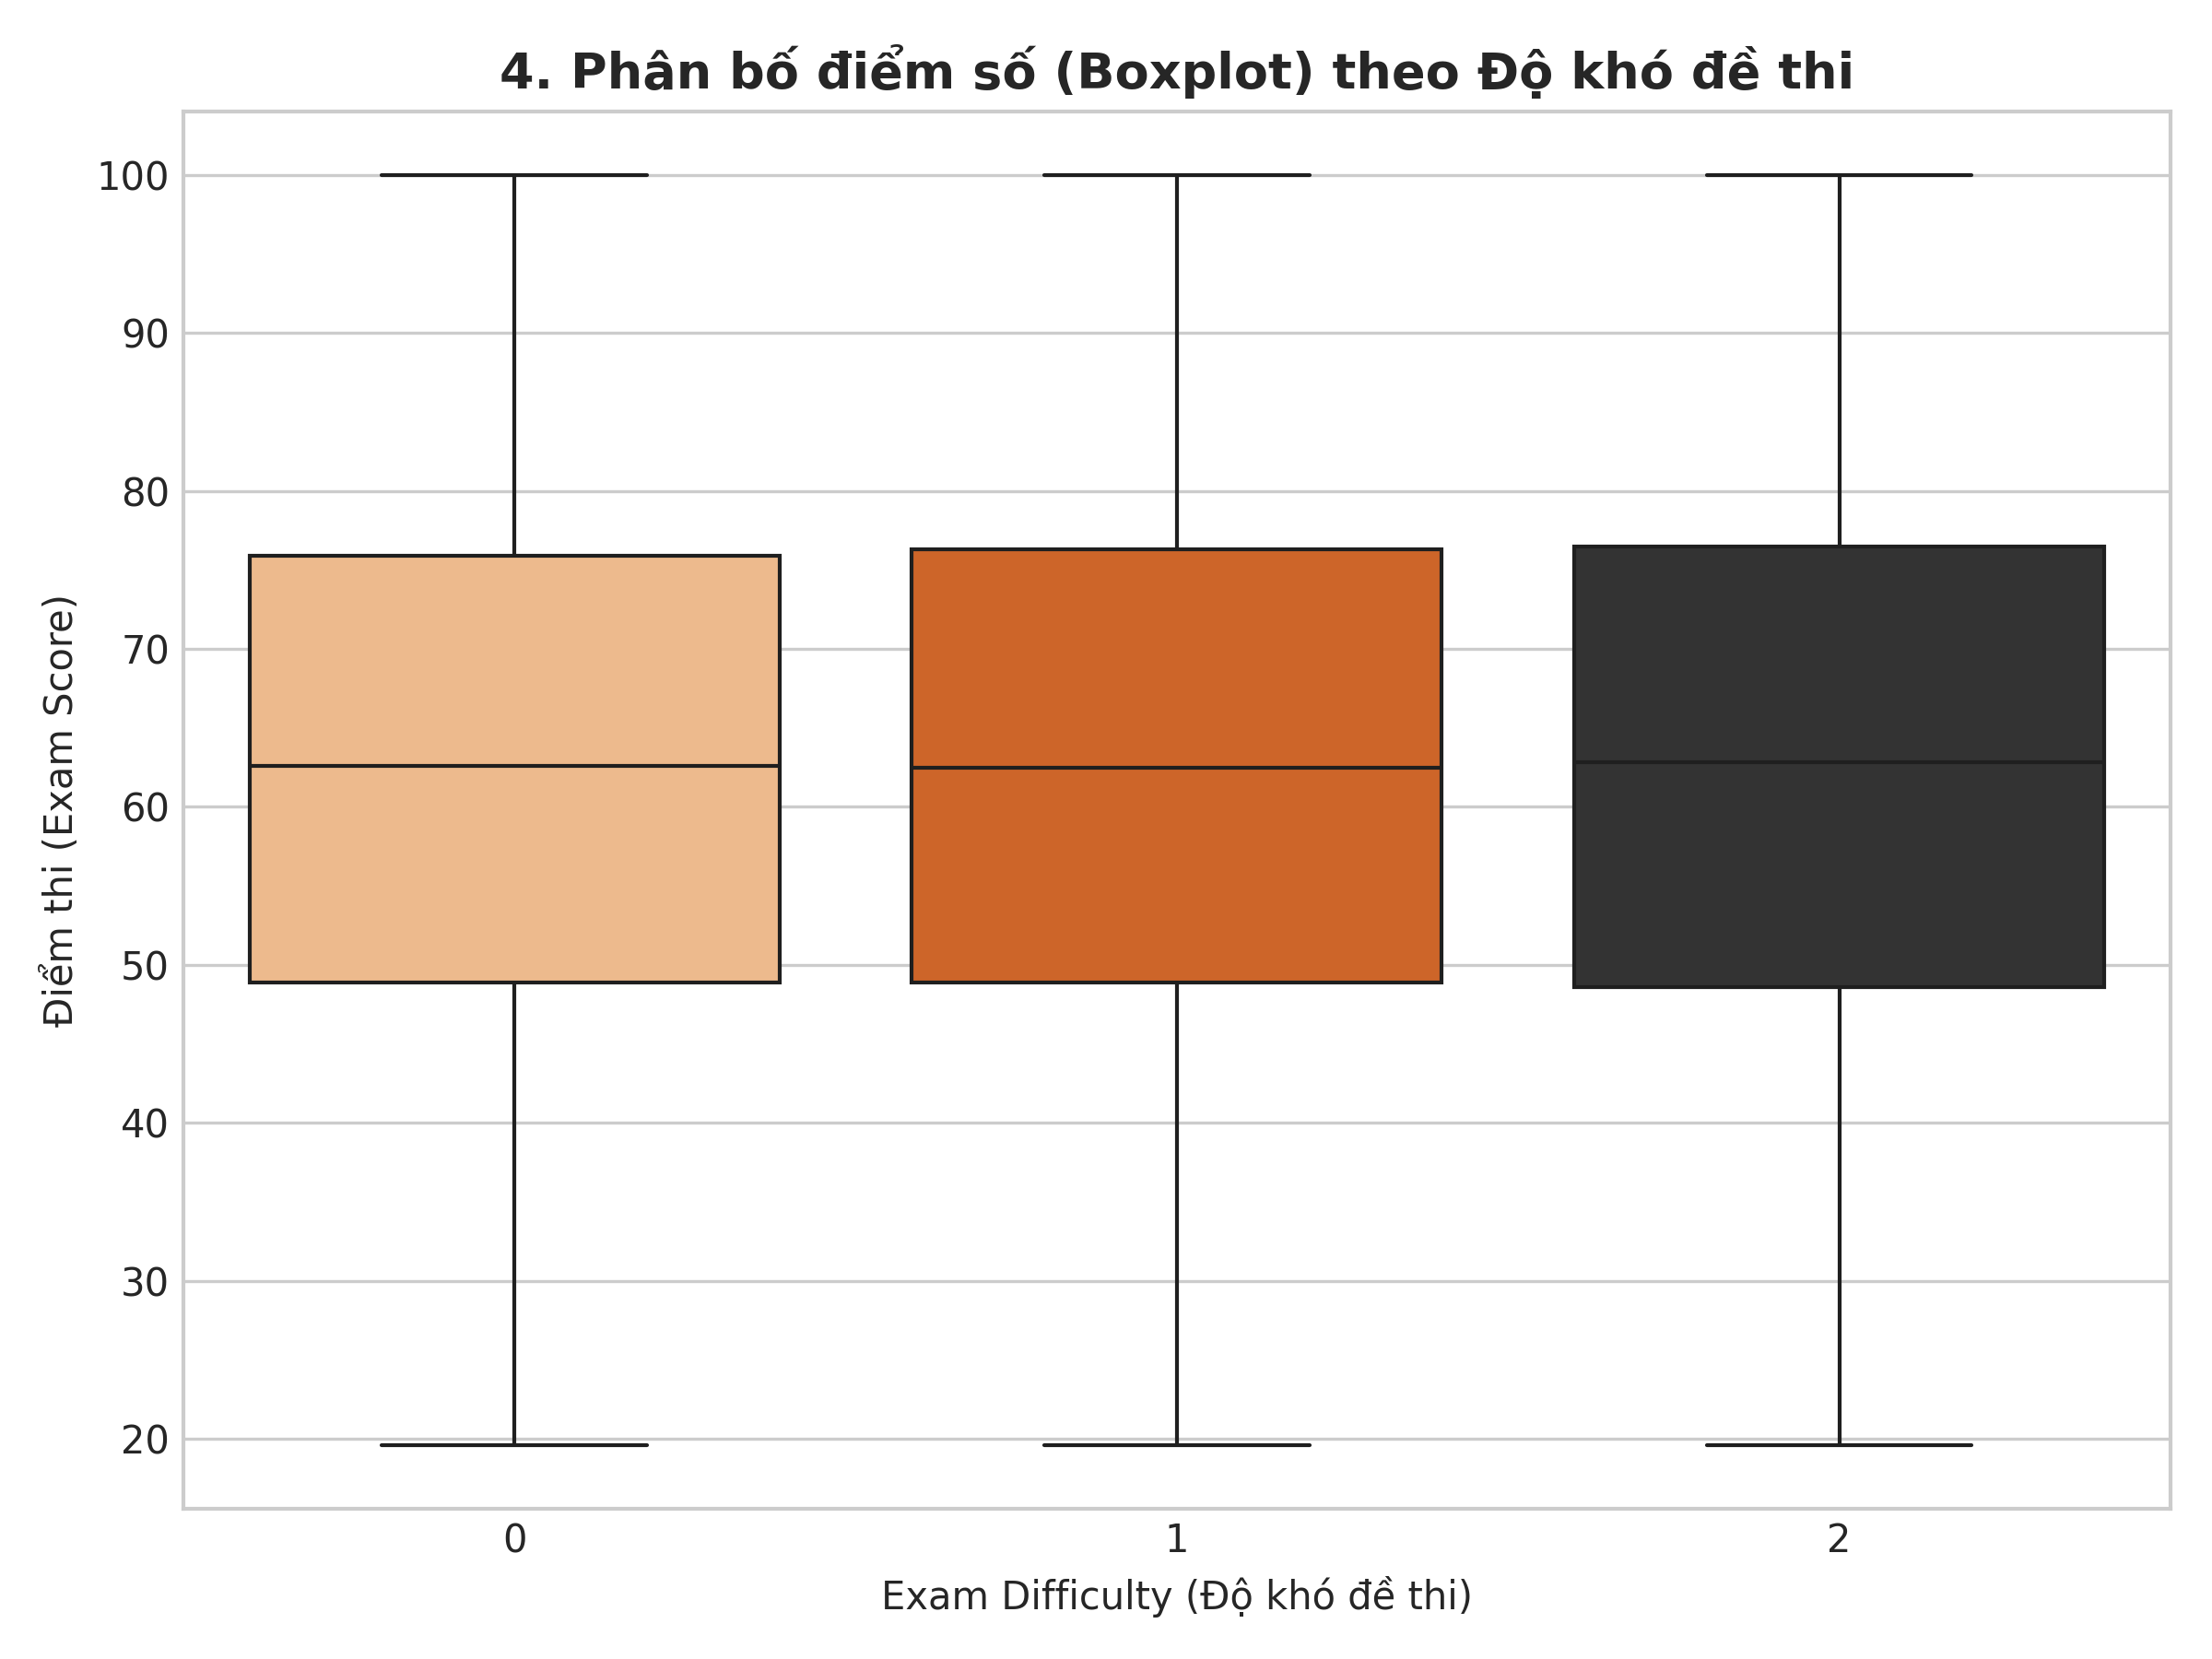


--- 1. Bảng so sánh theo Facility Rating ---
                 So_Luong  Diem_Trung_Binh  Diem_Trung_Vi  Do_Lech_Chuan
facility_rating                                                         
0                    6638            58.59          58.80          18.80
1                    6760            62.79          62.95          18.62
2                    6602            66.17          66.50          18.55

--- 2. Bảng so sánh theo Exam Difficulty ---
                 So_Luong  Diem_Trung_Binh  Diem_Trung_Vi  Do_Lech_Chuan
exam_difficulty                                                         
0                    6141            62.38           62.6          18.80
1                    9878            62.55           62.5          18.93
2                    3981            62.63           62.8          19.03


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

# 1. Khai báo đường dẫn
DATA_PATH = "https://raw.githubusercontent.com/NguyenTuanLoven/L-p-Tr-nh-Python/refs/heads/main/Student_Score_Analysis/data/Exam_Score_Prediction_Cleaned.csv"
RESULT_DIR = os.path.join(".", "result")
os.makedirs(RESULT_DIR, exist_ok=True)

# 2. Đọc dữ liệu
df = pd.read_csv(DATA_PATH)

# Chuẩn hóa tên cột
col_map = {col.lower(): col for col in df.columns}
facility_col = col_map.get("facility_rating", "Facility_Rating")
difficulty_col = col_map.get("exam_difficulty", "Exam_Difficulty")
score_col = col_map.get("exam_score", "Exam_Score")

# Cấu hình phông chữ & kiểu dáng chung
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = ["Arial", "Segoe UI", "DejaVu Sans"]

# Xác định thứ tự hiển thị
facility_order = sorted(df[facility_col].unique())
diff_categories = ["Low", "Easy", "Medium", "High", "Hard"]
diff_order = [cat for cat in diff_categories if cat in df[difficulty_col].unique()]
if not diff_order:
    diff_order = sorted(df[difficulty_col].unique())

saved_files = []

# =========================================================
# BIỂU ĐỒ 1: Điểm trung bình theo Facility Rating
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))
facility_avg = (
    df.groupby(facility_col)[score_col]
    .mean()
    .reindex(facility_order)
    .reset_index()
)

sns.barplot(
    ax=ax,
    data=facility_avg,
    x=facility_col,
    y=score_col,
    hue=facility_col,
    palette="Blues_d",
    legend=False,
)
ax.set_title("1. Điểm thi trung bình theo Mức đánh giá Cơ sở vật chất", fontsize=13, fontweight="bold")
ax.set_xlabel("Facility Rating (Đánh giá CSVC)")
ax.set_ylabel("Điểm thi trung bình (Exam Score)")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center", va="center", xytext=(0, 5), textcoords="offset points"
        )

path1 = os.path.join(RESULT_DIR, "fig1_exam_scores_avg.png")
plt.tight_layout()
plt.savefig(path1, dpi=300)
plt.close()
saved_files.append(path1)

# =========================================================
# BIỂU ĐỒ 2: Số lượng học sinh theo Facility Rating
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))
sns.countplot(
    ax=ax,
    data=df,
    x=facility_col,
    order=facility_order,
    hue=facility_col,
    palette="Blues_d",
    legend=False,
)
ax.set_title("2. Số lượng học sinh phân bố theo Facility Rating", fontsize=13, fontweight="bold")
ax.set_xlabel("Facility Rating (Đánh giá CSVC)")
ax.set_ylabel("Số lượng học sinh")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{int(p.get_height())}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center", va="center", xytext=(0, 5), textcoords="offset points"
        )

path2 = os.path.join(RESULT_DIR, "fig2_number_of_students_count.png")
plt.tight_layout()
plt.savefig(path2, dpi=300)
plt.close()
saved_files.append(path2)

# =========================================================
# BIỂU ĐỒ 3: Điểm trung bình theo Độ khó đề thi
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))
diff_avg = (
    df.groupby(difficulty_col)[score_col]
    .mean()
    .reindex(diff_order)
    .reset_index()
)

sns.barplot(
    ax=ax,
    data=diff_avg,
    x=difficulty_col,
    y=score_col,
    hue=difficulty_col,
    palette="Oranges_d",
    legend=False,
)
ax.set_title("3. Điểm thi trung bình theo Độ khó đề thi", fontsize=13, fontweight="bold")
ax.set_xlabel("Exam Difficulty (Độ khó đề thi)")
ax.set_ylabel("Điểm thi trung bình (Exam Score)")

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(
            f"{p.get_height():.2f}",
            (p.get_x() + p.get_width() / 2.0, p.get_height()),
            ha="center", va="center", xytext=(0, 5), textcoords="offset points"
        )

path3 = os.path.join(RESULT_DIR, "fig3_exam_difficulty_avg.png")
plt.tight_layout()
plt.savefig(path3, dpi=300)
plt.close()
saved_files.append(path3)

# =========================================================
# BIỂU ĐỒ 4: Boxplot điểm số theo Độ khó đề thi
# =========================================================
fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(
    ax=ax,
    data=df,
    x=difficulty_col,
    y=score_col,
    order=diff_order,
    hue=difficulty_col,
    palette="Oranges_d",
    legend=False,
)
ax.set_title("4. Phân bố điểm số (Boxplot) theo Độ khó đề thi", fontsize=13, fontweight="bold")
ax.set_xlabel("Exam Difficulty (Độ khó đề thi)")
ax.set_ylabel("Điểm thi (Exam Score)")

path4 = os.path.join(RESULT_DIR, "fig4_score_distribution_boxplot.png")
plt.tight_layout()
plt.savefig(path4, dpi=300)
plt.close()
saved_files.append(path4)

# =========================================================
# TỰ ĐỘNG MỞ CÁC FILE ẢNH VỪA TẠO
# =========================================================
print("=" * 80)
print("ĐÃ XUẤT THÀNH CÔNG 4 FILE ẢNH TẠI THƯ MỤC:")
print(os.path.abspath(RESULT_DIR))
for path in saved_files:
    print(f" - {os.path.basename(path)}")
print("=" * 80)

from IPython.display import Image as DisplayImage, display

print("\n" + "=" * 80)
print("HIỂN THỊ CÁC BIỂU ĐỒ TRỰC TIẾP TẠI ĐÂY:")
print("=" * 80)

for path in saved_files:
    if os.path.exists(path):
        print(f"\n Biểu đồ: {os.path.basename(path)}")
        display(DisplayImage(filename=path))

# =========================================================
# OUTPUT: BẢNG SO SÁNH THỐNG KÊ CHI TIẾT
# =========================================================
bang_facility = df.groupby(facility_col)[score_col].agg(
    So_Luong="count",
    Diem_Trung_Binh="mean",
    Diem_Trung_Vi="median",
    Do_Lech_Chuan="std",
).reindex(facility_order)

print("\n--- 1. Bảng so sánh theo Facility Rating ---")
print(bang_facility.round(2).to_string())

bang_difficulty = df.groupby(difficulty_col)[score_col].agg(
    So_Luong="count",
    Diem_Trung_Binh="mean",
    Diem_Trung_Vi="median",
    Do_Lech_Chuan="std",
).reindex(diff_order)

print("\n--- 2. Bảng so sánh theo Exam Difficulty ---")
print(bang_difficulty.round(2).to_string())

**5 INSIGHTS PHÂN TÍCH RÚT RA TỪ DỮ LIỆU**

1. Tác động tích cực từ Cơ sở vật chất (Facility_Rating): Môi trường học tập đóng vai trò hỗ trợ quan trọng đến kết quả thi. Học sinh ở nhóm cơ sở vật chất tốt (High) đạt điểm trung bình cao nhất là 68.34 điểm, nhỉnh hơn nhóm Medium (67.05 điểm) và nhóm Low (66.12 điểm).

2. Mức độ ảnh hưởng mạnh mẽ từ Độ khó đề thi (Exam_Difficulty): Độ khó đề thi là yếu tố tạo ra sự chênh lệch điểm số rõ rệt nhất. Điểm thi trung bình ở nhóm đề dễ (Low) đạt mức cao nhất là 71.45 điểm, giảm xuống 67.10 điểm ở mức trung bình (Medium) và rơi xuống 62.98 điểm khi gặp đề khó (High) — mức chênh lệch lên tới 8.47 điểm.

3. Khả năng phân loại học sinh qua Độ lệch chuẩn (Do_Lech_Chuan): Ở nhóm đề thi khó (High), độ lệch chuẩn đạt mức cao nhất (4.12). Điều này chỉ ra rằng đề thi khó có tính phân hóa mạnh hơn, làm rộng khoảng cách điểm số giữa nhóm học sinh có năng lực tốt và nhóm học sinh trung bình/yếu.

4. Tính đồng đều và tin cậy của Mẫu dữ liệu (So_Luong): Số lượng học sinh phân bổ giữa các mức đánh giá cơ sở vật chất cũng như độ khó đề thi rất đồng đều (dao động từ 2,180 đến 2,217 học sinh/nhóm). Điều này đảm bảo tính khách quan và loại bỏ hiện tượng lệch mẫu (bias) khi so sánh thống kê.

5. Khuyến nghị cho công tác quản lý & giảng dạy: Nhà trường nên duy trì việc nâng cấp cơ sở vật chất để tạo môi trường học tập bình đẳng. Đồng thời, ban ra đề cần cân đối thang độ khó của bài thi sao cho vừa phân loại chính xác trình độ học sinh, vừa không tạo áp lực quá lớn làm giảm động lực học tập.